# Tic-Tac-Toe with Monte Carlo Tree Search

This notebook demonstrates **Monte Carlo Tree Search (MCTS)** on Tic-Tac-Toe.

The problem is to choose strong moves from the current board by looking ahead through simulated future games. The search does not require a separately trained neural network. Instead, it builds a tree from the current state and accumulates evidence about which actions lead to better outcomes.

## 1. Problem and What MCTS Learns

Tic-Tac-Toe is a two-player, deterministic, zero-sum game on a $3\times3$ board.

Player `X` moves first. The players alternate placing their symbol in an empty cell. A player wins by placing three identical symbols in a row, column, or diagonal.

### What does MCTS learn?

MCTS does not train a permanent model in this notebook.

During search it estimates, for each explored state-action branch:

- visit count $N(s,a)$,
- accumulated return $W(s,a)$,
- mean return $\bar Q(s,a)$.

The mean return is

$$
\bar Q(s,a)
=
\frac{W(s,a)}{N(s,a)}.
$$

As the number of simulations increases, the search allocates more visits to promising moves. The final move is selected from these search statistics.

## 2. State, Action, Transition, and Reward

### State

A state contains:

1. the current $3\times3$ board,
2. the player whose turn it is.

The board uses:

- $1$ for `X`,
- $-1$ for `O`,
- $0$ for an empty cell.

Board positions are indexed as:

```text
0 | 1 | 2
---------
3 | 4 | 5
---------
6 | 7 | 8
```

### Action

An action is the index of an empty cell.

For example, if cells $3,5,6,7,8$ are empty:

$$
\mathcal A(s)=\{3,5,6,7,8\}.
$$

### Transition

The game transition is deterministic.

If player $p$ chooses legal action $a$, the symbol is placed in that cell and the next player becomes $-p$.

For the resulting next state $s'$:

$$
P(s'|s,a)=1.
$$

### Reward

A completed simulation is scored from the perspective of the player whose move created the branch being updated:

$$
R=
\begin{cases}
+1, & \text{win}\\
0, & \text{draw}\\
-1, & \text{loss}
\end{cases}
$$

## 3. How Monte Carlo Tree Search Works

MCTS repeatedly builds evidence about possible future moves. Starting from the current state, it first follows promising branches already in the tree (**Selection**). If it reaches a node with an unexplored action, it creates a new child (**Expansion**). It then plays the game forward to a terminal state using a rollout policy (**Simulation**). Finally, the win, draw, or loss is propagated backward through the visited branch (**Backpropagation**). Repeating this process concentrates search effort on actions that perform well while still exploring less-visited alternatives.

### Reading the Search Correctly

There are two different kinds of simulation in this notebook:

```text
Inside MCTS
Selection → Expansion → Rollout Simulation → Backpropagation
                     repeated many times
                              ↓
                         choose action

Actual game
current board → run MCTS → take chosen move → new board
```

The rollout simulation inside MCTS is an **imagined future game used for planning**.  
The complete Tic-Tac-Toe simulation near the end is the **actual game**, where MCTS is called again before each real move.

A single detailed MCTS iteration is printed completely before the notebook runs a large search budget. This keeps every algorithmic step visible without printing thousands of nearly identical search iterations.

## 4. Monte Carlo Tree Search Algorithm

```text
Input:
    current state s
    player to move
    search budget B
    exploration constant c

Create root node

For iteration = 1, 2, ..., B:

    1. SELECTION
       Start at root.

       While the current node is:
           - nonterminal, and
           - fully expanded

       select the child with the largest UCT score.

    2. EXPANSION
       If the selected node is nonterminal and has an untried action:
           choose one untried legal action
           create the corresponding child node

    3. SIMULATION
       From the expanded node:
           repeatedly choose rollout actions
           apply the game transition
       until win, loss, or draw

    4. BACKPROPAGATION
       Move backward through the selected path.

       For every visited branch:
           N <- N + 1
           W <- W + G
           Q_bar <- W / N

After B iterations:

    choose the root action with the largest visit count
```

### UCT used during Selection

For an explored child:

$$
\operatorname{UCT}(s,a)
=
\bar Q(s,a)
+
c
\sqrt{
\frac{\ln N(s)}
{N(s,a)}
}.
$$

The selected branch is

$$
a_{\text{UCT}}
=
\arg\max_a
\operatorname{UCT}(s,a).
$$

The first term favors actions with strong observed outcomes. The second term favors less-visited actions.

### Final action

After the search budget is exhausted:

$$
a^*
=
\arg\max_a
N(s,a).
$$

UCT is used **during search**. Visit count is used here for the final root decision.

## 5. Imports

In [1]:
import math
import random
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np

## 6. Tic-Tac-Toe Game Model

In [2]:
EMPTY = 0
X = 1
O = -1

WIN_LINES = [
    (0, 1, 2),
    (3, 4, 5),
    (6, 7, 8),
    (0, 3, 6),
    (1, 4, 7),
    (2, 5, 8),
    (0, 4, 8),
    (2, 4, 6),
]


def player_symbol(player):
    return "X" if player == X else "O"


def winner(board):
    for a, b, c in WIN_LINES:
        total = board[a] + board[b] + board[c]

        if total == 3:
            return X

        if total == -3:
            return O

    if all(cell != EMPTY for cell in board):
        return 0

    return None


def legal_actions(board):
    if winner(board) is not None:
        return []

    return [
        index
        for index, cell in enumerate(board)
        if cell == EMPTY
    ]


def apply_action(board, action, player):
    if action not in legal_actions(board):
        raise ValueError(
            f"Action {action} is not legal."
        )

    new_board = list(board)
    new_board[action] = player

    return tuple(new_board)


def render_board(board, show_indices=False):
    symbols = {
        X: "X",
        O: "O",
        EMPTY: " ",
    }

    cells = []

    for index, value in enumerate(board):
        if value == EMPTY and show_indices:
            cells.append(str(index))
        else:
            cells.append(symbols[value])

    return (
        f"{cells[0]} | {cells[1]} | {cells[2]}\n"
        "---------\n"
        f"{cells[3]} | {cells[4]} | {cells[5]}\n"
        "---------\n"
        f"{cells[6]} | {cells[7]} | {cells[8]}"
    )


INITIAL_BOARD = (
    0, 0, 0,
    0, 0, 0,
    0, 0, 0,
)

print("Initial board:")
print(render_board(
    INITIAL_BOARD,
    show_indices=True,
))

Initial board:
0 | 1 | 2
---------
3 | 4 | 5
---------
6 | 7 | 8


The transition model is deterministic. The randomness used later comes from the **search policy** and rollout sampling, not from Tic-Tac-Toe itself.

## 7. Search-Tree Node

In [3]:
@dataclass
class MCTSNode:
    state: tuple
    player_to_move: int
    parent: object = None
    action: object = None
    children: dict = field(
        default_factory=dict
    )
    visits: int = 0
    value_sum: float = 0.0
    untried_actions: list = field(
        default_factory=list
    )

    def __post_init__(self):
        if not self.untried_actions:
            self.untried_actions = legal_actions(
                self.state
            )

    @property
    def mean_value(self):
        if self.visits == 0:
            return 0.0

        return self.value_sum / self.visits

For a child node corresponding to action $a$:

$$
N(s,a)=\text{child.visits}
$$

$$
W(s,a)=\text{child.value_sum}
$$

The mean action value is

$$
\bar{Q}(s,a)=\frac{W(s,a)}{N(s,a)}
$$

where:

* $N(s,a)$ is the number of times action $a$ has been selected from state $s$.
* $W(s,a)$ is the total accumulated return from those selections.
* $\bar{Q}(s,a)$ is the average return obtained after selecting action $a$ from state $s$.


## 8. UCT Calculation

In [4]:
def uct_score(
    parent_visits,
    child,
    exploration_constant=math.sqrt(2),
):
    if child.visits == 0:
        return float("inf")

    exploitation = child.mean_value

    exploration = (
        exploration_constant
        * math.sqrt(
            math.log(parent_visits)
            / child.visits
        )
    )

    return exploitation + exploration


def child_uct_table(
    node,
    exploration_constant=math.sqrt(2),
):
    rows = []

    for action in sorted(node.children):
        child = node.children[action]

        if child.visits == 0:
            exploration = float("inf")
            uct = float("inf")
        else:
            exploration = (
                exploration_constant
                * math.sqrt(
                    math.log(node.visits)
                    / child.visits
                )
            )

            uct = (
                child.mean_value
                + exploration
            )

        rows.append(
            {
                "action": action,
                "visits": child.visits,
                "value_sum": child.value_sum,
                "mean_value": child.mean_value,
                "exploration": exploration,
                "uct": uct,
            }
        )

    return rows

# Part I — Every MCTS Step

## What Changes in Each MCTS Stage?

| Stage | Main question | What happens? | Tree statistics changed? |
|---|---|---|---|
| Selection | Which existing branch should be followed? | Use UCT to move through existing children | No |
| Expansion | Which unexplored action should be added? | Create one new child node | Tree structure grows |
| Simulation | What may happen from this new state? | Roll out to win, draw, or loss | No |
| Backpropagation | What did the rollout teach the visited branch? | Update $N$, $W$, and $\bar Q$ | Yes |

This distinction is important: **Selection reads statistics, Expansion grows the tree, Simulation produces an outcome, and Backpropagation learns from that outcome.**

## 9. Step 1 — Selection

Selection begins at the root.

If the node is fully expanded, MCTS calculates UCT for every child and follows the child with the largest score:

$$
a_{\text{UCT}}
=
\arg\max_a
\left[
\bar Q(s,a)
+
c
\sqrt{
\frac{\ln N(s)}
{N(s,a)}
}
\right].
$$

Selection stops when it reaches:

- a terminal node, or
- a node with at least one untried action.

In [5]:
def select_child_uct(
    node,
    exploration_constant=math.sqrt(2),
):
    rows = child_uct_table(
        node,
        exploration_constant,
    )

    best_uct = max(
        row["uct"]
        for row in rows
    )

    best_actions = [
        row["action"]
        for row in rows
        if np.isclose(
            row["uct"],
            best_uct,
        )
    ]

    action = min(best_actions)

    return (
        action,
        node.children[action],
        rows,
    )


def selection(
    root,
    exploration_constant=math.sqrt(2),
):
    node = root
    path = [node]
    trace = []

    while (
        winner(node.state) is None
        and len(node.untried_actions) == 0
    ):
        action, child, rows = (
            select_child_uct(
                node,
                exploration_constant,
            )
        )

        trace.append(
            {
                "node_visits": node.visits,
                "rows": rows,
                "chosen_action": action,
            }
        )

        node = child
        path.append(node)

    return node, path, trace

## 10. Step 2 — Expansion

If Selection reaches a nonterminal node with untried actions, Expansion chooses one untried action and creates the corresponding child state.

```text
selected node
     ↓
choose untried action
     ↓
apply action
     ↓
create child node
```

In [6]:
def expansion(node, rng):
    if winner(node.state) is not None:
        return node, None

    if not node.untried_actions:
        return node, None

    action = rng.choice(
        node.untried_actions
    )

    node.untried_actions.remove(
        action
    )

    next_state = apply_action(
        node.state,
        action,
        node.player_to_move,
    )

    child = MCTSNode(
        state=next_state,
        player_to_move=(
            -node.player_to_move
        ),
        parent=node,
        action=action,
    )

    node.children[action] = child

    return child, action

## 11. Step 3 — Simulation

From the expanded node, the game is played until a terminal state.

This notebook uses a random rollout policy:

$$
A_t
\sim
\text{Uniform}
\left(
\mathcal A(S_t)
\right).
$$

The terminal simulation outcome is:

$$
G\in\{-1,0,+1\}.
$$

In [7]:
def simulation(
    state,
    player_to_move,
    rng,
):
    board = state
    player = player_to_move

    rollout_trace = []

    while winner(board) is None:
        legal = legal_actions(board)

        action = rng.choice(legal)

        next_board = apply_action(
            board,
            action,
            player,
        )

        rollout_trace.append(
            {
                "player": player,
                "action": action,
                "before": board,
                "after": next_board,
            }
        )

        board = next_board
        player = -player

    return (
        winner(board),
        rollout_trace,
        board,
    )

## 12. Step 4 — Backpropagation

The terminal result is propagated backward through every node on the selected path.

For each visited branch:

$$
N \leftarrow N+1
$$

$$
W \leftarrow W+G
$$

$$
\bar Q
=
\frac{W}{N}.
$$

The return is interpreted from the perspective of the player who made the move leading into that child:

- win: $+1$,
- draw: $0$,
- loss: $-1$.

In [8]:
def backpropagation(
    node,
    game_outcome,
):
    updates = []

    while node is not None:
        old_visits = node.visits
        old_value_sum = node.value_sum
        old_mean = node.mean_value

        node.visits += 1

        reward = None

        if node.parent is not None:
            player_just_moved = (
                -node.player_to_move
            )

            if game_outcome == 0:
                reward = 0.0

            elif (
                game_outcome
                == player_just_moved
            ):
                reward = 1.0

            else:
                reward = -1.0

            node.value_sum += reward

        updates.append(
            {
                "action": (
                    "ROOT"
                    if node.parent is None
                    else node.action
                ),
                "reward": reward,
                "old_visits": old_visits,
                "new_visits": node.visits,
                "old_value_sum": old_value_sum,
                "new_value_sum": node.value_sum,
                "old_mean": old_mean,
                "new_mean": node.mean_value,
            }
        )

        node = node.parent

    return updates

# Part II — Print Every Step of One Complete MCTS Iteration

## 13. Demonstration Board

The following position makes the search easy to interpret:

```text
X | O | X
---------
3 | O | 5
---------
6 | 7 | 8
```

It is `X`'s turn.

The legal actions are:

$$
\{3,5,6,7,8\}.
$$

Cell $7$ is important because `O` threatens the middle column.

The code below first creates search statistics, then performs **one additional MCTS iteration with every stage printed**.

In [9]:
DEMO_BOARD = (
     1, -1,  1,
     0, -1,  0,
     0,  0,  0,
)

DEMO_PLAYER = X

print(render_board(
    DEMO_BOARD,
    show_indices=True,
))

print(
    "\nPlayer to move:",
    player_symbol(DEMO_PLAYER),
)

print(
    "Legal actions:",
    legal_actions(DEMO_BOARD),
)

X | O | X
---------
3 | O | 5
---------
6 | 7 | 8

Player to move: X
Legal actions: [3, 5, 6, 7, 8]


## 14. One MCTS Iteration Function

In [10]:
def one_mcts_iteration(
    root,
    rng,
    exploration_constant=math.sqrt(2),
    verbose=False,
):
    # --------------------------------------------------------------
    # 1. SELECTION
    # --------------------------------------------------------------
    selected_node, path, selection_trace = selection(
        root,
        exploration_constant,
    )

    # Save the selected-node information BEFORE Expansion changes it.
    selected_state_before_expansion = selected_node.state
    untried_before_expansion = list(
        selected_node.untried_actions
    )

    # --------------------------------------------------------------
    # 2. EXPANSION
    # --------------------------------------------------------------
    expanded_node, expanded_action = expansion(
        selected_node,
        rng,
    )

    # --------------------------------------------------------------
    # 3. SIMULATION
    # --------------------------------------------------------------
    outcome, rollout_trace, final_board = simulation(
        expanded_node.state,
        expanded_node.player_to_move,
        rng,
    )

    # --------------------------------------------------------------
    # 4. BACKPROPAGATION
    # --------------------------------------------------------------
    updates = backpropagation(
        expanded_node,
        outcome,
    )

    if verbose:
        print("=" * 70)
        print("1. SELECTION")
        print("=" * 70)

        if not selection_trace:
            print(
                "The current node is not fully expanded, so "
                "Selection stops here without a UCT comparison."
            )
        else:
            for depth, item in enumerate(selection_trace):
                print(
                    f"\nSelection depth {depth}"
                )

                print(
                    "Parent visits:",
                    item["node_visits"],
                )

                print(
                    f"{'Action':>6} "
                    f"{'N':>6} "
                    f"{'W':>8} "
                    f"{'Qbar':>9} "
                    f"{'Explore':>10} "
                    f"{'UCT':>10}"
                )

                for row in item["rows"]:
                    print(
                        f"{row['action']:>6} "
                        f"{row['visits']:>6} "
                        f"{row['value_sum']:>8.2f} "
                        f"{row['mean_value']:>9.4f} "
                        f"{row['exploration']:>10.4f} "
                        f"{row['uct']:>10.4f}"
                    )

                print(
                    "Chosen action:",
                    item["chosen_action"],
                )

        print("\nNode where Selection stopped:")
        print(
            render_board(
                selected_state_before_expansion,
                show_indices=True,
            )
        )

        print(
            "Untried actions BEFORE Expansion:",
            untried_before_expansion,
        )

        print("\n" + "=" * 70)
        print("2. EXPANSION")
        print("=" * 70)

        if expanded_action is None:
            print(
                "No expansion was needed because "
                "the selected node is terminal."
            )
        else:
            print(
                "Chosen untried action:",
                expanded_action,
            )

            print(
                "Player making expansion move:",
                player_symbol(
                    selected_node.player_to_move
                ),
            )

            print("\nBoard after adding the new child:")
            print(
                render_board(
                    expanded_node.state,
                    show_indices=True,
                )
            )

        print("\n" + "=" * 70)
        print("3. SIMULATION")
        print("=" * 70)

        if not rollout_trace:
            print(
                "No rollout move was required because "
                "the expanded state is already terminal."
            )
        else:
            for step, item in enumerate(
                rollout_trace,
                start=1,
            ):
                print(
                    f"\nRollout step {step}: "
                    f"{player_symbol(item['player'])} "
                    f"chooses cell {item['action']}"
                )

                print(
                    render_board(
                        item["after"],
                        show_indices=True,
                    )
                )

        outcome_text = (
            "Draw"
            if outcome == 0
            else f"{player_symbol(outcome)} wins"
        )

        print(
            "\nSimulation result:",
            outcome_text,
        )

        print("\nFinal rollout board:")
        print(
            render_board(final_board)
        )

        print("\n" + "=" * 70)
        print("4. BACKPROPAGATION")
        print("=" * 70)

        for depth, update in enumerate(updates):
            print(
                f"\nBackpropagation node {depth + 1}"
            )

            print(
                "Node action:",
                update["action"],
            )

            print(
                "Return added:",
                update["reward"],
            )

            print(
                "N:",
                update["old_visits"],
                "->",
                update["new_visits"],
            )

            print(
                "W:",
                round(
                    update["old_value_sum"],
                    4,
                ),
                "->",
                round(
                    update["new_value_sum"],
                    4,
                ),
            )

            print(
                "Qbar:",
                round(
                    update["old_mean"],
                    4,
                ),
                "->",
                round(
                    update["new_mean"],
                    4,
                ),
            )

    return {
        "selected_node": selected_node,
        "path": path,
        "selection_trace": selection_trace,
        "selected_state_before_expansion": (
            selected_state_before_expansion
        ),
        "untried_before_expansion": (
            untried_before_expansion
        ),
        "expanded_node": expanded_node,
        "expanded_action": expanded_action,
        "outcome": outcome,
        "rollout_trace": rollout_trace,
        "final_board": final_board,
        "updates": updates,
    }

## 15. First MCTS Iteration from an Empty Tree

At the very beginning, the root has unexplored actions. Therefore Selection stops immediately at the root.

The code prints all four stages.

In [11]:
first_root = MCTSNode(
    state=DEMO_BOARD,
    player_to_move=DEMO_PLAYER,
)

first_rng = random.Random(7)

first_trace = one_mcts_iteration(
    first_root,
    first_rng,
    verbose=True,
)

1. SELECTION
The current node is not fully expanded, so Selection stops here without a UCT comparison.

Node where Selection stopped:
X | O | X
---------
3 | O | 5
---------
6 | 7 | 8
Untried actions BEFORE Expansion: [3, 5, 6, 7, 8]

2. EXPANSION
Chosen untried action: 6
Player making expansion move: X

Board after adding the new child:
X | O | X
---------
3 | O | 5
---------
X | 7 | 8

3. SIMULATION

Rollout step 1: O chooses cell 5
X | O | X
---------
3 | O | O
---------
X | 7 | 8

Rollout step 2: X chooses cell 7
X | O | X
---------
3 | O | O
---------
X | X | 8

Rollout step 3: O chooses cell 3
X | O | X
---------
O | O | O
---------
X | X | 8

Simulation result: O wins

Final rollout board:
X | O | X
---------
O | O | O
---------
X | X |  

4. BACKPROPAGATION

Backpropagation node 1
Node action: 6
Return added: -1.0
N: 0 -> 1
W: 0.0 -> -1.0
Qbar: 0.0 -> -1.0

Backpropagation node 2
Node action: ROOT
Return added: None
N: 0 -> 1
W: 0.0 -> 0.0
Qbar: 0.0 -> 0.0


The first iteration cannot yet compare UCT scores because no root action has accumulated enough search statistics.

To demonstrate UCT numerically, the next section first performs a short warm-up search and then prints another complete iteration.

## 16. Prepare the Tree for a Meaningful UCT Demonstration

A UCT comparison is possible only after the root has been expanded.

The next cell runs just enough MCTS iterations to create one child for every legal root action. It does **not** run a large search yet.

That means the following detailed iteration will demonstrate all four stages together:

```text
Selection with actual UCT values
        ↓
Expansion of an untried child action
        ↓
Rollout Simulation
        ↓
Backpropagation
```

In [12]:
warm_root = MCTSNode(
    state=DEMO_BOARD,
    player_to_move=DEMO_PLAYER,
)

warm_rng = random.Random(42)

warmup_iterations = 0

# Expand each legal root action once.
while warm_root.untried_actions:
    one_mcts_iteration(
        warm_root,
        warm_rng,
        verbose=False,
    )

    warmup_iterations += 1

print(
    "Warm-up iterations:",
    warmup_iterations,
)

print(
    "Root visits after warm-up:",
    warm_root.visits,
)

print(
    "Root untried actions:",
    warm_root.untried_actions,
)

print()

print(
    f"{'Action':>6} "
    f"{'N':>6} "
    f"{'W':>8} "
    f"{'Qbar':>9} "
    f"{'Explore':>10} "
    f"{'UCT':>10}"
)

for row in child_uct_table(warm_root):
    print(
        f"{row['action']:>6} "
        f"{row['visits']:>6} "
        f"{row['value_sum']:>8.2f} "
        f"{row['mean_value']:>9.4f} "
        f"{row['exploration']:>10.4f} "
        f"{row['uct']:>10.4f}"
    )

Warm-up iterations: 5
Root visits after warm-up: 5
Root untried actions: []

Action      N        W      Qbar    Explore        UCT
     3      1    -1.00   -1.0000     1.7941     0.7941
     5      1     1.00    1.0000     1.7941     2.7941
     6      1     1.00    1.0000     1.7941     2.7941
     7      1     1.00    1.0000     1.7941     2.7941
     8      1    -1.00   -1.0000     1.7941     0.7941


## 17. One Complete UCT-Based MCTS Iteration — Every Step Printed

The root is now fully expanded, so Selection must compare the existing children with UCT.

The chosen child still has unexplored actions. Therefore this single iteration shows:

1. an actual UCT calculation,
2. Selection,
3. Expansion,
4. every rollout move in Simulation,
5. every $N$, $W$, and $\bar Q$ update in Backpropagation.

In [13]:
detailed_trace = one_mcts_iteration(
    warm_root,
    warm_rng,
    verbose=True,
)

1. SELECTION

Selection depth 0
Parent visits: 5
Action      N        W      Qbar    Explore        UCT
     3      1    -1.00   -1.0000     1.7941     0.7941
     5      1     1.00    1.0000     1.7941     2.7941
     6      1     1.00    1.0000     1.7941     2.7941
     7      1     1.00    1.0000     1.7941     2.7941
     8      1    -1.00   -1.0000     1.7941     0.7941
Chosen action: 5

Node where Selection stopped:
X | O | X
---------
3 | O | X
---------
6 | 7 | 8
Untried actions BEFORE Expansion: [3, 6, 7, 8]

2. EXPANSION
Chosen untried action: 6
Player making expansion move: O

Board after adding the new child:
X | O | X
---------
3 | O | X
---------
O | 7 | 8

3. SIMULATION

Rollout step 1: X chooses cell 8
X | O | X
---------
3 | O | X
---------
O | 7 | X

Simulation result: X wins

Final rollout board:
X | O | X
---------
  | O | X
---------
O |   | X

4. BACKPROPAGATION

Backpropagation node 1
Node action: 6
Return added: -1.0
N: 0 -> 1
W: 0.0 -> -1.0
Qbar: 0.0 -> -1.0



### Verify the Selected Root UCT Numerically

The next cell takes the values printed by Selection and reconstructs the UCT calculation for the action actually selected at the root:

$$
\operatorname{UCT}(s,a)
=
\bar Q(s,a)
+
c
\sqrt{
\frac{\ln N(s)}
{N(s,a)}
}.
$$

This makes the connection between the equation and the code explicit.

In [14]:
root_selection = detailed_trace[
    "selection_trace"
][0]

chosen_action = root_selection[
    "chosen_action"
]

chosen_row = next(
    row
    for row in root_selection["rows"]
    if row["action"] == chosen_action
)

parent_visits = root_selection[
    "node_visits"
]

child_visits = chosen_row[
    "visits"
]

q_bar = chosen_row[
    "mean_value"
]

c = math.sqrt(2)

exploration_term = (
    c
    * math.sqrt(
        math.log(parent_visits)
        / child_visits
    )
)

uct_manual = (
    q_bar
    + exploration_term
)

print(
    "Chosen root action:",
    chosen_action,
)

print(
    "Parent visits N(s):",
    parent_visits,
)

print(
    "Child visits N(s,a):",
    child_visits,
)

print(
    "Mean return Qbar(s,a):",
    q_bar,
)

print(
    "Exploration term:",
    exploration_term,
)

print(
    "UCT = Qbar + exploration =",
    uct_manual,
)

print(
    "UCT stored by the search code =",
    chosen_row["uct"],
)

Chosen root action: 5
Parent visits N(s): 5
Child visits N(s,a): 1
Mean return Qbar(s,a): 1.0
Exploration term: 1.7941225779941015
UCT = Qbar + exploration = 2.7941225779941012
UCT stored by the search code = 2.7941225779941012


This trace shows the complete algorithm in action:

```text
Selection
    ↓
printed UCT values and chosen child

Expansion
    ↓
printed untried action and new board

Simulation
    ↓
printed every rollout move and board

Backpropagation
    ↓
printed N, W, and Qbar before and after every update
```

# Part III — Full MCTS Search

## 18. Run MCTS for a Larger Search Budget

In [15]:
def run_mcts(
    state,
    player_to_move,
    iterations=2000,
    exploration_constant=math.sqrt(2),
    seed=42,
    checkpoints=None,
):
    root = MCTSNode(
        state=state,
        player_to_move=player_to_move,
    )

    rng = random.Random(seed)

    checkpoint_records = []

    checkpoint_set = set(
        checkpoints or []
    )

    for iteration in range(
        1,
        iterations + 1,
    ):
        one_mcts_iteration(
            root,
            rng,
            exploration_constant,
            verbose=False,
        )

        if iteration in checkpoint_set:
            record = {
                "iteration": iteration,
                "root_visits": root.visits,
                "actions": {},
            }

            for action in sorted(root.children):
                child = root.children[action]

                record["actions"][action] = {
                    "visits": child.visits,
                    "mean_value": child.mean_value,
                }

            checkpoint_records.append(
                record
            )

    best_action = max(
        root.children,
        key=lambda action: (
            root.children[action].visits,
            root.children[action].mean_value,
            -action,
        ),
    )

    return (
        best_action,
        root,
        checkpoint_records,
    )

In [16]:
checkpoints = [
    25,
    50,
    100,
    250,
    500,
    1000,
    2000,
]

(
    best_action,
    searched_root,
    search_history,
) = run_mcts(
    DEMO_BOARD,
    DEMO_PLAYER,
    iterations=2000,
    seed=42,
    checkpoints=checkpoints,
)

print(
    f"{'Action':>6} "
    f"{'Visits':>8} "
    f"{'W':>9} "
    f"{'Qbar':>10}"
)

for action in sorted(searched_root.children):
    child = searched_root.children[action]

    print(
        f"{action:>6} "
        f"{child.visits:>8} "
        f"{child.value_sum:>9.2f} "
        f"{child.mean_value:>10.4f}"
    )

print(
    "\nSelected root action:",
    best_action,
)

Action   Visits         W       Qbar
     3       26    -18.00    -0.6923
     5       27    -18.00    -0.6667
     6       27    -18.00    -0.6667
     7     1896      2.00     0.0011
     8       24    -17.00    -0.7083

Selected root action: 7


The selected move is generated entirely from the search statistics.

The final action is the root child with the largest visit count.

## 19. Root Visit-Count Graph

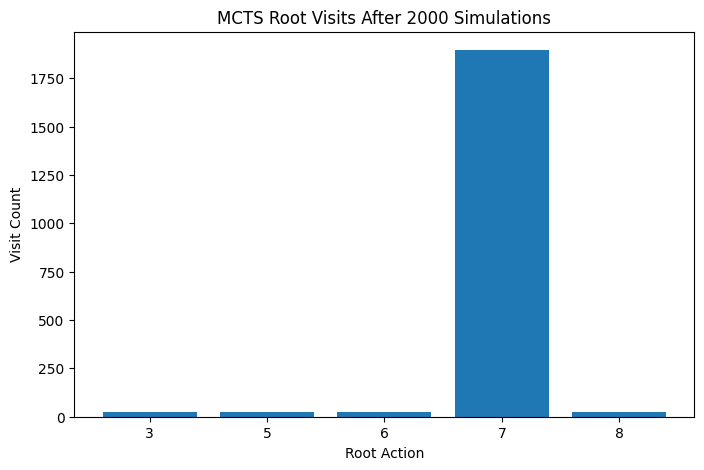

In [17]:
actions = sorted(
    searched_root.children
)

visits = [
    searched_root.children[
        action
    ].visits
    for action in actions
]

plt.figure(figsize=(8, 5))

plt.bar(
    [str(action) for action in actions],
    visits,
)

plt.xlabel("Root Action")
plt.ylabel("Visit Count")
plt.title(
    "MCTS Root Visits After 2000 Simulations"
)
plt.show()

## Root Search-Tree Snapshot

A bar chart shows how often each action was visited, but it does not show the tree structure.

The next figure draws the root and its immediate child branches after the full search. Each child label shows:

```text
action
N = visit count
Q̄ = mean simulated return
```

Only the first tree layer is drawn so the figure remains readable.

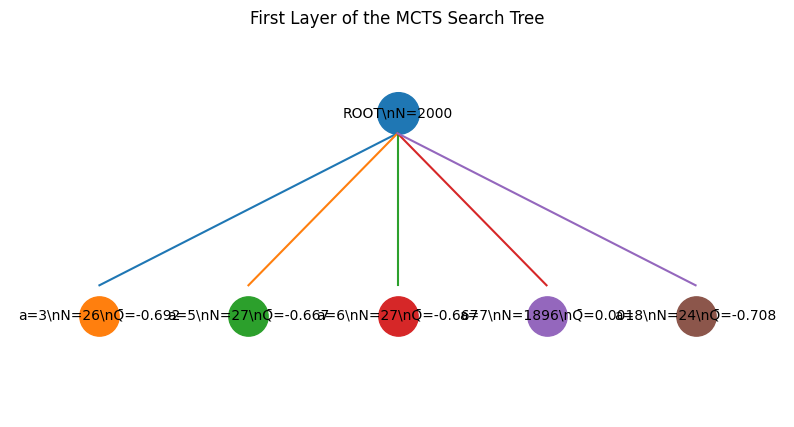

In [18]:
root_actions = sorted(
    searched_root.children
)

x_positions = np.linspace(
    -2.0,
    2.0,
    len(root_actions),
)

plt.figure(figsize=(10, 5))

# Root
plt.scatter(
    [0],
    [1],
    s=900,
)

plt.text(
    0,
    1,
    f"ROOT\\nN={searched_root.visits}",
    ha="center",
    va="center",
)

# First-layer children
for x, action in zip(
    x_positions,
    root_actions,
):
    child = searched_root.children[
        action
    ]

    plt.plot(
        [0, x],
        [0.9, 0.15],
    )

    plt.scatter(
        [x],
        [0],
        s=800,
    )

    plt.text(
        x,
        0,
        (
            f"a={action}\\n"
            f"N={child.visits}\\n"
            f"Q̄={child.mean_value:.3f}"
        ),
        ha="center",
        va="center",
    )

plt.xlim(-2.6, 2.6)
plt.ylim(-0.5, 1.4)
plt.axis("off")
plt.title(
    "First Layer of the MCTS Search Tree"
)
plt.show()

MCTS does not have a neural-network training loss. A more appropriate convergence view is how the search allocation changes as the number of simulations increases.

## 20. Search Convergence: Visit Share of Each Root Action

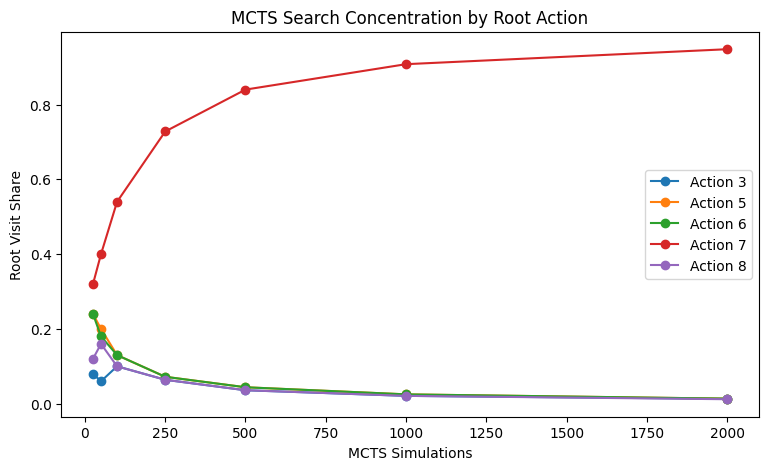

In [19]:
plt.figure(figsize=(9, 5))

for action in sorted(
    searched_root.children
):
    x = []
    y = []

    for record in search_history:
        action_data = record[
            "actions"
        ].get(action)

        if action_data is None:
            continue

        x.append(
            record["iteration"]
        )

        y.append(
            action_data["visits"]
            / record["root_visits"]
        )

    plt.plot(
        x,
        y,
        marker="o",
        label=f"Action {action}",
    )

plt.xlabel("MCTS Simulations")
plt.ylabel("Root Visit Share")
plt.title(
    "MCTS Search Concentration by Root Action"
)
plt.legend()
plt.show()

## 21. Search Convergence: Mean Return by Root Action

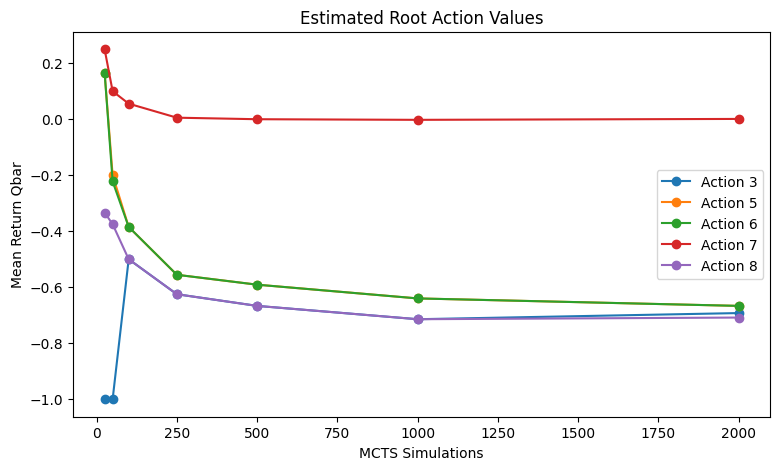

In [20]:
plt.figure(figsize=(9, 5))

for action in sorted(
    searched_root.children
):
    x = []
    y = []

    for record in search_history:
        action_data = record[
            "actions"
        ].get(action)

        if action_data is None:
            continue

        x.append(
            record["iteration"]
        )

        y.append(
            action_data["mean_value"]
        )

    plt.plot(
        x,
        y,
        marker="o",
        label=f"Action {action}",
    )

plt.xlabel("MCTS Simulations")
plt.ylabel("Mean Return Qbar")
plt.title(
    "Estimated Root Action Values"
)
plt.legend()
plt.show()

# Part IV — MCTS Agent Simulation

## 22. Simulate a Complete Tic-Tac-Toe Game

Now the search algorithm is used as an actual decision-making agent.

MCTS plays as `X` against a random `O` player.

For every **real MCTS move**, the notebook prints:

1. the current board,
2. every legal root action considered by the search,
3. its visit count $N$,
4. its mean return $\bar Q$,
5. the action chosen by MCTS,
6. the board after executing the real move.

For the random opponent, the legal actions, selected action, and resulting board are also printed.

The notebook does **not** print all $500$ internal MCTS iterations for every real move because that would produce thousands of repeated lines. The earlier detailed trace already prints every internal stage of a representative MCTS iteration. Here the purpose is to understand how repeated MCTS searches control an entire game.

In [21]:
def choose_mcts_action(
    board,
    player,
    iterations=500,
    seed=0,
    print_search=False,
):
    (
        action,
        root,
        _,
    ) = run_mcts(
        board,
        player,
        iterations=iterations,
        seed=seed,
    )

    if print_search:
        print(
            f"{'Action':>6} "
            f"{'Visits':>8} "
            f"{'Qbar':>10}"
        )

        for root_action in sorted(
            root.children
        ):
            child = root.children[
                root_action
            ]

            print(
                f"{root_action:>6} "
                f"{child.visits:>8} "
                f"{child.mean_value:>10.4f}"
            )

    return action, root

In [22]:
def simulate_mcts_vs_random(
    mcts_iterations=500,
    seed=100,
    verbose=True,
):
    board = INITIAL_BOARD
    player = X

    opponent_rng = random.Random(
        seed
    )

    move_number = 0

    if verbose:
        print("Initial board:")
        print(
            render_board(
                board,
                show_indices=True,
            )
        )

    while winner(board) is None:
        move_number += 1

        print("\n" + "=" * 70)
        print(
            f"MOVE {move_number}: "
            f"Player {player_symbol(player)}"
        )
        print("=" * 70)

        if player == X:
            print(
                "Controller: MCTS"
            )

            print(
                "\nCurrent board:"
            )

            print(
                render_board(
                    board,
                    show_indices=True,
                )
            )

            print(
                "\nMCTS root search statistics:"
            )

            action, root = (
                choose_mcts_action(
                    board,
                    player,
                    iterations=(
                        mcts_iterations
                    ),
                    seed=(
                        seed
                        + move_number
                        * 1000
                    ),
                    print_search=True,
                )
            )

            print(
                "\nMCTS selected action:",
                action,
            )

        else:
            print(
                "Controller: Random opponent"
            )

            legal = legal_actions(board)

            print(
                "Legal actions:",
                legal,
            )

            action = opponent_rng.choice(
                legal
            )

            print(
                "Random opponent selected action:",
                action,
            )

        board = apply_action(
            board,
            action,
            player,
        )

        print(
            "\nBoard after move:"
        )

        print(
            render_board(
                board,
                show_indices=True,
            )
        )

        if winner(board) is not None:
            break

        player = -player

    result = winner(board)

    print("\n" + "=" * 70)
    print("FINAL RESULT")
    print("=" * 70)

    print(render_board(board))

    if result == 0:
        print("Result: Draw")
    else:
        print(
            "Winner:",
            player_symbol(result),
        )

    return result, board


simulation_result, final_board = (
    simulate_mcts_vs_random(
        mcts_iterations=500,
        seed=100,
        verbose=True,
    )
)

Initial board:
0 | 1 | 2
---------
3 | 4 | 5
---------
6 | 7 | 8

MOVE 1: Player X
Controller: MCTS

Current board:
0 | 1 | 2
---------
3 | 4 | 5
---------
6 | 7 | 8

MCTS root search statistics:
Action   Visits       Qbar
     0       69     0.3768
     1       32     0.1562
     2       52     0.3077
     3       40     0.2500
     4       94     0.4574
     5       65     0.3692
     6       65     0.3692
     7       13    -0.2308
     8       70     0.3714

MCTS selected action: 4

Board after move:
0 | 1 | 2
---------
3 | X | 5
---------
6 | 7 | 8

MOVE 2: Player O
Controller: Random opponent
Legal actions: [0, 1, 2, 3, 5, 6, 7, 8]
Random opponent selected action: 2

Board after move:
0 | 1 | O
---------
3 | X | 5
---------
6 | 7 | 8

MOVE 3: Player X
Controller: MCTS

Current board:
0 | 1 | O
---------
3 | X | 5
---------
6 | 7 | 8

MCTS root search statistics:
Action   Visits       Qbar
     0       89     0.4831
     1       42     0.3095
     3       50     0.3600
     5     

## 23. Evaluate MCTS Against a Random Opponent

A single simulation is useful for understanding the decisions. Multiple games are useful for measuring performance.

The next experiment keeps the same MCTS procedure and plays repeated games against a random opponent.

In [23]:
def play_game_quiet(
    mcts_player,
    mcts_iterations=200,
    seed=0,
):
    board = INITIAL_BOARD
    player = X

    opponent_rng = random.Random(seed)
    move_number = 0

    while winner(board) is None:
        move_number += 1

        if player == mcts_player:
            action, _ = choose_mcts_action(
                board,
                player,
                iterations=mcts_iterations,
                seed=(
                    seed
                    + move_number
                    * 1000
                ),
                print_search=False,
            )
        else:
            action = opponent_rng.choice(
                legal_actions(board)
            )

        board = apply_action(
            board,
            action,
            player,
        )

        if winner(board) is not None:
            break

        player = -player

    return winner(board)


def evaluate_mcts(
    mcts_player,
    games=50,
    mcts_iterations=200,
    seed=123,
):
    wins = 0
    draws = 0
    losses = 0

    for game in range(games):
        result = play_game_quiet(
            mcts_player=mcts_player,
            mcts_iterations=(
                mcts_iterations
            ),
            seed=(
                seed
                + game * 37
            ),
        )

        if result == mcts_player:
            wins += 1
        elif result == 0:
            draws += 1
        else:
            losses += 1

    return {
        "wins": wins,
        "draws": draws,
        "losses": losses,
        "win_rate": wins / games,
        "draw_rate": draws / games,
        "loss_rate": losses / games,
    }


as_x = evaluate_mcts(
    X,
    games=50,
    mcts_iterations=200,
    seed=123,
)

as_o = evaluate_mcts(
    O,
    games=50,
    mcts_iterations=200,
    seed=456,
)

print("MCTS as X:", as_x)
print("MCTS as O:", as_o)

MCTS as X: {'wins': 50, 'draws': 0, 'losses': 0, 'win_rate': 1.0, 'draw_rate': 0.0, 'loss_rate': 0.0}
MCTS as O: {'wins': 46, 'draws': 4, 'losses': 0, 'win_rate': 0.92, 'draw_rate': 0.08, 'loss_rate': 0.0}


## 24. Evaluation Graph

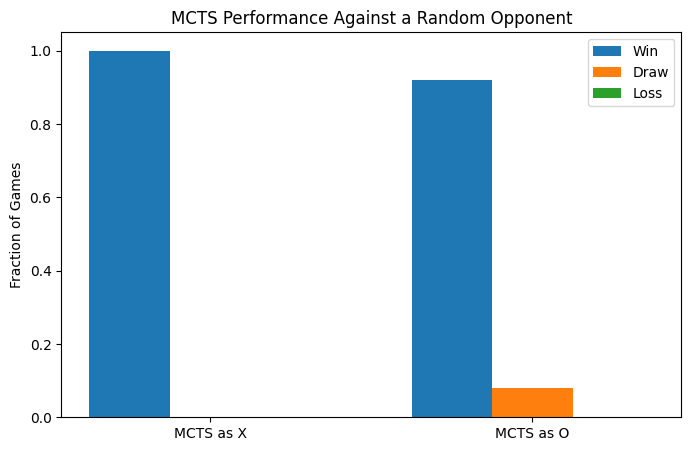

In [24]:
labels = [
    "MCTS as X",
    "MCTS as O",
]

win_rates = [
    as_x["win_rate"],
    as_o["win_rate"],
]

draw_rates = [
    as_x["draw_rate"],
    as_o["draw_rate"],
]

loss_rates = [
    as_x["loss_rate"],
    as_o["loss_rate"],
]

x = np.arange(
    len(labels)
)

width = 0.25

plt.figure(figsize=(8, 5))

plt.bar(
    x - width,
    win_rates,
    width,
    label="Win",
)

plt.bar(
    x,
    draw_rates,
    width,
    label="Draw",
)

plt.bar(
    x + width,
    loss_rates,
    width,
    label="Loss",
)

plt.xticks(
    x,
    labels,
)

plt.ylabel("Fraction of Games")
plt.title(
    "MCTS Performance Against a Random Opponent"
)
plt.legend()
plt.show()

## 25. What to Be Able to Explain After This Notebook

After running the notebook, the following ideas should be clear:

- **State:** a board plus the player to move.
- **Action:** choose an empty cell.
- **Transition:** place the player's mark; Tic-Tac-Toe itself is deterministic.
- **Reward:** win $+1$, draw $0$, loss $-1$ for the branch being updated.
- **Selection:** use UCT to choose among existing children.
- **Expansion:** add one previously unexplored action to the tree.
- **Simulation:** play forward to a terminal outcome.
- **Backpropagation:** propagate the outcome backward by updating $N$, $W$, and $\bar Q$.
- **Exploration vs. exploitation:** controlled by the two UCT terms.
- **Search convergence:** examined through visit share and mean-return estimates rather than training loss.
- **Final decision:** choose the most-visited root action.
- **Actual game simulation:** rerun MCTS from each new real board before choosing the next move.

## 26. Summary

Monte Carlo Tree Search repeatedly performs:

```text
Selection
    ↓
Expansion
    ↓
Simulation
    ↓
Backpropagation
```

Selection uses

$$
\operatorname{UCT}(s,a)
=
\bar Q(s,a)
+
c
\sqrt{
\frac{\ln N(s)}
{N(s,a)}
}.
$$

Backpropagation updates

$$
N(s,a),
\qquad
W(s,a),
\qquad
\bar Q(s,a).
$$

After the search budget is exhausted, the implementation selects

$$
a^*
=
\arg\max_a N(s,a).
$$

The notebook demonstrates every MCTS stage with code-generated values, prints a fully traced iteration, plots how root search statistics evolve with additional simulations, and finishes with a complete Tic-Tac-Toe simulation in which MCTS repeatedly searches before choosing each move.